In [4]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df,df1],ignore_index=True)

df = df.sample(40)
     

df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [5]:
import plotly.express as px
fig = px.scatter_3d(df , x= df['feature1'] , y =df['feature2'] , z=df['feature3'] , 
                    color=df['target'].astype('str'))

fig.update_traces(marker=dict(size=6 , line = dict(width=2 , color='DarkSlateGrey')) ,
                  selector=dict(mode='markers'))
fig.show()

In [6]:
# Step 1 Finding Mean 

from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
df.iloc[:,0:3] = scalar.fit_transform(df.iloc[:,0:3])

In [7]:
# Step 2 find Covariance matrix

cov_matx = np.cov([df.iloc[:,0],df.iloc[:,1] , df.iloc[:,3]]) 
print("Covariance Matrix is \n" , cov_matx)

Covariance Matrix is 
 [[ 1.02564103  0.20478114 -0.13345475]
 [ 0.20478114  1.02564103 -0.26828336]
 [-0.13345475 -0.26828336  0.25641026]]


In [8]:
# Eigen Values and Eigen Vector

eigen_values , eigen_vectors  = np.linalg.eig(cov_matx)

In [9]:
eigen_values

array([1.30850646, 0.83252896, 0.16665689])

In [10]:
eigen_vectors

array([[ 0.64431258,  0.7603462 ,  0.08206675],
       [ 0.71749616, -0.63814109,  0.27924039],
       [-0.26468954,  0.12103552,  0.95670782]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


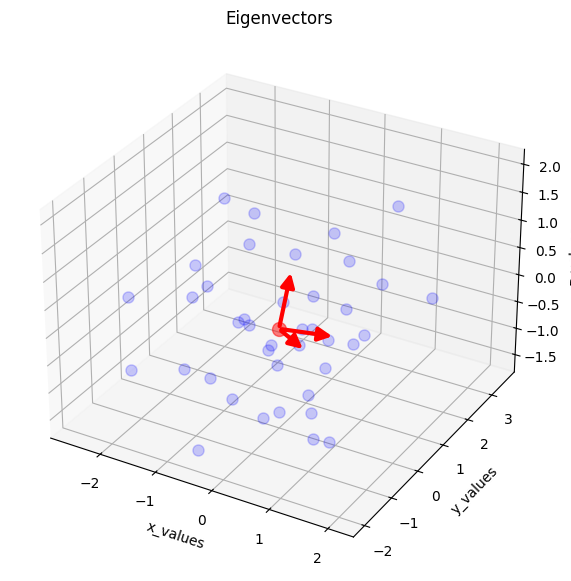

In [11]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d

        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.M
        )

        self.set_positions(
            (xs[0], ys[0]),
            (xs[1], ys[1])
        )

        return min(zs)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)

# Mean point
ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)

# Eigenvectors
for v in eigen_vectors.T:

    a = Arrow3D(
        [df['feature1'].mean(), df['feature1'].mean() + v[0]],
        [df['feature2'].mean(), df['feature2'].mean() + v[1]],
        [df['feature3'].mean(), df['feature3'].mean() + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )

    ax.add_artist(a)


ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')
plt.show()

In [12]:
pc = eigen_vectors[0:2]
pc

array([[ 0.64431258,  0.7603462 ,  0.08206675],
       [ 0.71749616, -0.63814109,  0.27924039]])

In [13]:
transform_df = np.dot(df.iloc[:,0:3] , pc.T)

# we have data of shape (40,3) and pca is  (2,3) taking transpose of pca is (3,2)
# dot product of this (40,3)  . (3,2) give us (40,2)

new_df = pd.DataFrame(transform_df , columns=['PC1' , 'PC2'])

new_df['target'] = df['target'].values 
new_df.head()

,PC1,PC2,target
0,-1.755061,-0.017724,1
1,-0.872846,0.621118,0
2,-0.096380,-0.159668,1
3,0.035675,1.246779,1
4,-1.888958,-1.668862,1


In [14]:
fig = px.scatter(x= new_df['PC1'] , y =new_df['PC2'] , 
                    color=new_df['target'].astype('str'),
                    color_discrete_sequence=px.colors.qualitative.G10)

fig.update_traces(marker=dict(size=6 , line = dict(width=2 , color='DarkSlateGrey')) ,
                  selector=dict(mode='markers'))
fig.show()